# Public Precipitation Data

This notebook retrieves and compares precipitation observations from publicly accessible archives that are independent of the CROCUS sensor network. It is intended both as a practical data-access notebook and as an introduction to the scientific differences among precipitation datasets.

The notebook uses four sources:

1. **NOAA NCEI GHCN-Daily** for quality-reviewed daily climate records.
2. **Iowa Environmental Mesonet ASOS/AWOS** for hourly airport precipitation reports.
3. **USGS Water Data** for precipitation measurements at hydrologic monitoring sites.
4. **CoCoRaHS through IEM** for daily reports from volunteer observers.

The Metropolitan Water Reclamation District of Greater Chicago (MWRD) rain-gauge viewer is discussed near the end, but its data are not yet retrieved automatically.

Reusable data-access functions are kept in `precipitation.py`. The notebook contains location-specific configuration, examples, visualization, interpretation, and source documentation.

## Precipitation measurements are not interchangeable

A number labeled “daily precipitation” may represent different observing periods and instruments.

| Source | Typical native resolution | Observing period | Important consideration |
|---|---:|---|---|
| GHCN-Daily | Daily | Station reporting day | The observation may not be midnight-to-midnight. |
| ASOS/AWOS | Hourly reports | Previous hour | Trace amounts and missing reports require explicit handling. |
| USGS | Often 5–60 minutes | Site- and series-dependent | Inspect metadata before treating values as interval totals. |
| CoCoRaHS | Daily | Usually morning-to-morning | Volunteer stations may report intermittently. |

Precipitation can also vary substantially over short distances, especially during convective storms. Differences among nearby stations do not necessarily indicate that one instrument is wrong.

This notebook standardizes precipitation **units** to millimeters, but it does not pretend that all reporting intervals are identical.

## Data services

### NOAA NCEI Global Historical Climatology Network-Daily

The Global Historical Climatology Network-Daily (GHCN-Daily) integrates daily climate observations from many networks and applies a common quality-assurance system.

This notebook uses NOAA's public GHCN-Daily files for both station discovery and observations:

1. `ghcnd-stations.txt` and `ghcnd-inventory.txt` identify nearby stations and their periods of record.
2. The `by_station/` directory provides one compressed CSV containing the full daily record for each station.

These files do not require an API token. They are cached locally after the first download so later runs are faster and do not repeatedly contact NOAA.

- [GHCN-Daily overview](https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily)
- [GHCN-Daily file documentation](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme.txt)
- [By-station file documentation](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme-by_station.txt)
- [GHCN-Daily public file directory](https://www.ncei.noaa.gov/pub/data/ghcn/daily/)

### Iowa Environmental Mesonet

IEM provides open station metadata, an ASOS/AWOS/METAR archive, and computed daily summaries for several networks, including CoCoRaHS.

- [IEM API documentation](https://mesonet.agron.iastate.edu/api/)
- [ASOS request-service documentation](https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?help=)
- [Notes about ASOS precipitation](https://mesonet.agron.iastate.edu/ASOS/precipnote.phtml)
- [Daily-summary request documentation](https://mesonet.agron.iastate.edu/cgi-bin/request/daily.py?help=)
- [IEM CoCoRaHS page](https://mesonet.agron.iastate.edu/cocorahs/)

### USGS Water Data

The modern USGS OGC APIs provide monitoring-location metadata, time-series metadata, and continuous observations. Precipitation uses parameter code `00045`.

- [USGS Water Data API documentation](https://api.waterdata.usgs.gov/docs/ogcapi/)
- [USGS Water Data APIs](https://api.waterdata.usgs.gov/)


## Dependencies and imports

The notebook requires:

```text
pandas
requests
matplotlib
python-dotenv
jupyter
```

`python-dotenv` loads credentials from a local `.env` file. The real `.env` file must be excluded from Git; `.env.example` can be committed as a safe template.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from precipitation import (
    PrecipitationDataError,
    aggregate_interval_precipitation_daily,
    find_asos_stations,
    find_cocorahs_stations,
    find_ghcnd_stations,
    find_usgs_precipitation_sites,
    get_asos_hourly_precipitation,
    get_cocorahs_precipitation,
    get_ghcnd_precipitation,
    ghcnd_to_cocorahs_id,
    get_usgs_precipitation,
    summarize_daily_precipitation_coverage,
)

pd.set_option("display.max_columns", 30)


## Credentials

The data services used in this notebook are publicly accessible and require no API keys. The repository's `.env` file is still used by other notebooks, such as the Ambient Weather archive notebook, but it is not needed here.


In [2]:
print("No credentials are required for this precipitation notebook.")


No credentials are required for this precipitation notebook.


## Location and date configuration

The defaults describe the NEIU main campus. Coordinates are used only to rank nearby stations by distance; they can be changed to study another location.

`START_DATE` and `END_DATE` are inclusive calendar dates. The ASOS and USGS functions require precise UTC timestamps, so the configuration below constructs an interval that includes the complete final date.

In [3]:
LOCATION_NAME = "Northeastern Illinois University"
LATITUDE = 41.9813
LONGITUDE = -87.7163
STATE = "IL"
TIMEZONE = "America/Chicago"

START_DATE = "2025-04-01"
END_DATE = "2025-06-30"

# Subdaily requests use the UTC instants corresponding to local midnight.
START_LOCAL = pd.Timestamp(START_DATE).tz_localize(TIMEZONE)
END_LOCAL_EXCLUSIVE = (
    pd.Timestamp(END_DATE) + pd.Timedelta(days=1)
).tz_localize(TIMEZONE)
START_UTC = START_LOCAL.tz_convert("UTC")
END_UTC = (
    END_LOCAL_EXCLUSIVE.tz_convert("UTC")
    - pd.Timedelta(seconds=1)
)

SEARCH_RADIUS_KM = 75
N_STATIONS = 5
GHCN_CANDIDATES = 10
GHCN_MINIMUM_COVERAGE = 0.80
GHCN_REFERENCE_STATION = None
GHCN_PLOT_STATIONS = 4

N_USGS_LOCATIONS = 3
USGS_MINIMUM_DAILY_COVERAGE = 0.95
USGS_MINIMUM_PERIOD_COVERAGE = 0.90
USGS_LOCATION_OVERRIDE = None

ASOS_COMPARISON_STATIONS = 2
COCORAHS_CANDIDATES = 25
GHCND_CACHE_DIR = Path("data/precipitation/cache/ghcnd")
GHCND_DATA_CACHE_DIR = GHCND_CACHE_DIR / "by_station"
FIGURE_DIR = Path("figures/precipitation")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RUN_GHCN = True
RUN_ASOS = True
RUN_USGS = True
RUN_COCORAHS = True

print(f"Location: {LOCATION_NAME} ({LATITUDE:.4f}, {LONGITUDE:.4f})")
print(f"Analysis period: {START_DATE} through {END_DATE}")
print(f"Subdaily UTC request window: {START_UTC} through {END_UTC}")

Location: Northeastern Illinois University (41.9813, -87.7163)
Analysis period: 2025-04-01 through 2025-06-30
Subdaily UTC request window: 2025-04-01 05:00:00+00:00 through 2025-07-01 04:59:59+00:00


## Station discovery

Station discovery and observation retrieval are separate operations:

1. Find stations near the target coordinates.
2. Inspect station names, distances, and periods of record.
3. Select stations appropriate for the analysis.
4. Retrieve observations for the selected dates.

The geographically nearest station is not always the best choice. A nearby station may be inactive, have substantial missing data, or report on a schedule that does not match another dataset.

### GHCN-Daily stations

Station discovery uses NOAA's public fixed-width station and inventory files rather than the token-based CDO station endpoint. On the first run, the notebook downloads the two metadata files, prints progress, and creates a compact precipitation-only cache under:

```text
data/precipitation/cache/ghcnd/
```

The first run is therefore slower than later runs, but it should show visible download and parsing messages rather than appearing to hang. Subsequent searches load the compact local cache and should complete quickly.

Set `refresh_cache=True` in the next cell only when you deliberately want to download current metadata again.


In [4]:
ghcnd_stations = pd.DataFrame()

if RUN_GHCN:
    try:
        ghcnd_stations = find_ghcnd_stations(
            LATITUDE,
            LONGITUDE,
            radius_km=SEARCH_RADIUS_KM,
            start=START_DATE,
            end=END_DATE,
            n_stations=GHCN_CANDIDATES,
            cache_dir=GHCND_CACHE_DIR,
            refresh_cache=False,
            verbose=True,
        )
        display(ghcnd_stations)
    except (PrecipitationDataError, ValueError) as exc:
        print(f"GHCN-Daily station search failed: {exc}")
else:
    print("GHCN-Daily station search skipped.")


Using cached GHCN-Daily metadata: data/precipitation/cache/ghcnd/ghcnd-prcp-stations.csv.gz


,station_id,station_name,state,latitude,longitude,elevation_m,first_year,last_year,distance_km
0,US1ILCK0395,CHICAGO 6.8 NW NEIU PHYSICS,IL,41.9803,-87.7171,180.7,2023,2025,0.129372
1,US1ILCK0323,CHICAGO 6.8 NW,IL,41.9625,-87.7042,181.7,2020,2026,2.317473
2,US1ILCK0168,RAVENSWOOD MANOR 0.1 ESE,IL,41.9642,-87.6974,178.3,2010,2026,2.461039
3,US1ILCK0214,ROGERS PARK 1.5 SW,IL,41.9957,-87.6918,181.4,2013,2026,2.581490
4,US1ILCK0094,LINCOLNWOOD 1.8 E,IL,42.0019,-87.6985,184.1,2008,2026,2.722317
5,US1ILCK0429,HARWOOD HEIGHTS 4.0 ESE,IL,41.9457,-87.7333,184.1,2024,2026,4.200684
6,US1ILCK0359,CHICAGO 5.5 NNW,IL,41.9502,-87.6815,182.3,2021,2026,4.498585
7,US1ILCK0232,ROGERS PARK 0.6 ESE,IL,42.0043,-87.6697,180.1,2014,2026,4.623023
8,US1ILCK0371,EVANSTON 1.2 S,IL,42.0291,-87.6926,185.3,2022,2026,5.664394
9,US1ILCK0321,EVANSTON 0.9 S,IL,42.0330,-87.6978,182.9,2020,2026,5.948531


### ASOS/AWOS stations

In [5]:
asos_stations = pd.DataFrame()

if RUN_ASOS:
    try:
        asos_stations = find_asos_stations(
            LATITUDE,
            LONGITUDE,
            state=STATE,
            radius_km=SEARCH_RADIUS_KM,
            n_stations=N_STATIONS,
        )
        display(asos_stations)
    except PrecipitationDataError as exc:
        print(f"ASOS station search failed: {exc}")
else:
    print("ASOS station search skipped.")


,station_id,station_name,latitude,longitude,elevation_m,network,time_zone,archive_begin,archive_end,online,distance_km
0,CGX,CHICAGO/MEIGS,41.8588,-87.6079,181.0,IL_ASOS,America/Chicago,1972-12-31,2011-12-31,False,16.308933
1,ORD,Chicago OHare,41.9602,-87.9316,205.0,IL_ASOS,America/Chicago,1946-10-01,NaN,True,17.953249
2,MDW,CHICAGO,41.7860,-87.7524,188.0,IL_ASOS,America/Chicago,1928-10-04,NaN,True,21.921070
3,PWK,PALWAUKEE,42.1208,-87.9047,203.0,IL_ASOS,America/Chicago,1995-07-08,NaN,True,21.968031
4,06C,Chicago - Schaumburg,41.9913,-88.1050,243.0,IL_ASOS,America/Chicago,2018-08-10,NaN,True,32.145979


### USGS precipitation time series

USGS precipitation parameter `00045` is often published as a continuous
**decumulated** interval series rather than an instantaneous point
measurement. Discovery therefore searches the USGS time-series metadata
without imposing `computation_identifier="Instantaneous"`.

The search retains only primary continuous time series whose periods of
record overlap the requested dates. It ranks monitoring locations by
distance, but preserves every qualifying time series at a selected location.
Multiple rows at one site can therefore represent distinct physical gauges
or sublocations rather than duplicate data.

In [6]:
usgs_sites = pd.DataFrame()

if RUN_USGS:
    try:
        usgs_sites = find_usgs_precipitation_sites(
            LATITUDE,
            LONGITUDE,
            radius_km=SEARCH_RADIUS_KM,
            start=START_UTC,
            end=END_UTC,
            n_locations=N_USGS_LOCATIONS,
            primary_only=True,
        )
        display(usgs_sites)
        print(
            f"Found {len(usgs_sites)} primary precipitation time series "
            f"at {usgs_sites['monitoring_location_id'].nunique()} "
            "nearby USGS monitoring locations."
        )
    except PrecipitationDataError as exc:
        print(f"USGS site search failed: {exc}")
else:
    print("USGS site search skipped.")

,time_series_id,monitoring_location_id,monitoring_location_name,site_type,latitude,longitude,distance_km,parameter_code,unit_of_measure,computation_identifier,computation_period_identifier,statistic_id,primary,sublocation_identifier,web_description,begin_utc,end_utc,data_gap_interval
0,fb84da8ce24a4bd68bf92369834aa15e,USGS-415755087525300,"OHARE AIRPORT AT CHICAGO, IL",Atmosphere,41.965308,-87.881453,13.768276,00045,in,Decumulated,Points,NaN,Primary,NaN,NaN,2007-10-01 11:00:00+00:00,2026-07-05 12:15:00+00:00,PT1H12M
1,011f29aeb4964022ae5580136c9b6cf0,USGS-420910087490701,"RAIN GAGE AT NB CHICAGO RIVER AT DEERFIELD, IL",Atmosphere,42.152778,-87.818611,20.854130,00045,in,Decumulated,Points,NaN,Primary,NaN,NaN,2018-04-09 18:45:00+00:00,2026-07-05 11:10:00+00:00,PT1H12M
2,da085401d70c4a939c2bdd5d2de23c0a,USGS-415518087583000,"ADDISON WWTF AT ADDISON, IL",Atmosphere,41.921696,-87.975066,22.401995,00045,in,Decumulated,Points,NaN,Primary,NaN,NaN,2007-10-01 11:00:00+00:00,2026-07-05 13:00:00+00:00,PT1H12M


Found 3 primary precipitation time series at 3 nearby USGS monitoring locations.


### CoCoRaHS stations

CoCoRaHS station metadata can include observers who no longer report regularly. We therefore search more candidates than we ultimately expect to use. The retrieval step below reveals which nearby stations actually submitted observations during the selected period.

In [7]:
cocorahs_stations = pd.DataFrame()

if RUN_COCORAHS:
    try:
        cocorahs_stations = find_cocorahs_stations(
            LATITUDE,
            LONGITUDE,
            state=STATE,
            radius_km=SEARCH_RADIUS_KM,
            n_stations=COCORAHS_CANDIDATES,
            start=START_DATE,
            end=END_DATE,
        )
        display(
            cocorahs_stations.head(10)[
                [
                    "station_id",
                    "station_name",
                    "distance_km",
                    "archive_begin",
                    "archive_end",
                ]
            ]
        )
        print(
            f"{len(cocorahs_stations)} nearby stations have archive "
            "periods overlapping the analysis dates."
        )
    except PrecipitationDataError as exc:
        print(f"CoCoRaHS station search failed: {exc}")
else:
    print("CoCoRaHS station search skipped.")

,station_id,station_name,distance_km,archive_begin,archive_end
0,IL-CK-395,Chicago 6.8 NW NEIU Physics,0.129372,2023-06-30,NaT
1,IL-CK-268,Lincolnwood 2.7 SSE,1.316800,NaT,NaT
2,IL-CK-408,Lincolnwood 1.5 SSW,1.936402,NaT,NaT
3,IL-CK-323,Chicago 6.8 NW,2.317473,2020-04-02,NaT
4,IL-CK-428,Chicago 6.9 NNW,2.368314,2024-06-26,2025-05-29
5,IL-CK-168,Ravenswood Manor 0.1 ESE,2.461039,2010-08-31,NaT
6,IL-CK-214,Rogers Park 1.5 SW,2.581490,2013-04-14,NaT
7,IL-CK-354,Lincolnwood 3.5 SSE,2.702357,NaT,NaT
8,IL-CK-94,Lincolnwood 1.8 E,2.722317,2008-03-11,NaT
9,IL-CK-8,Lincolnwood 3.4 ESE,3.659780,NaT,NaT


25 nearby stations have archive periods overlapping the analysis dates.


## GHCN-Daily precipitation

GHCN-Daily is the best source in this notebook for long, quality-reviewed daily climate records.

For each selected station, the retrieval function downloads NOAA's compressed full-period `by_station` file once and stores it under:

```text
data/precipitation/cache/ghcnd/by_station/
```

The function then filters the cached file to `START_DATE`, `END_DATE`, and the `PRCP` element. NOAA stores GHCN-Daily precipitation in tenths of a millimeter; the function converts it to millimeters.

The measurement, quality, source, and observation-time flags are preserved. A nonblank quality flag deserves investigation before the value is used in formal analysis.

The index is a **reporting date**, not a precise UTC instant. The station's observing schedule determines the interval represented by each daily value.


### Selecting a daily reference station

The closest gauge is not necessarily the best reference. A station can have a
nominally active period of record but report on only a small fraction of the
requested days. The notebook therefore computes each station's daily coverage
and selects the nearest station meeting `GHCN_MINIMUM_COVERAGE`. A manual
`GHCN_REFERENCE_STATION` override remains available for a scientifically
justified choice. Missing dates are never filled with zero precipitation.

In [8]:
ghcnd = pd.DataFrame()
ghcnd_coverage = pd.DataFrame()
ghcnd_reference_station = None

if RUN_GHCN and not ghcnd_stations.empty:
    selected_ghcnd = ghcnd_stations["station_id"].tolist()
    try:
        ghcnd = get_ghcnd_precipitation(
            selected_ghcnd,
            START_DATE,
            END_DATE,
            cache_dir=GHCND_DATA_CACHE_DIR,
            refresh_cache=False,
            verbose=True,
        )

        ghcnd_coverage = summarize_daily_precipitation_coverage(
            ghcnd,
            START_DATE,
            END_DATE,
            station_column="station_id",
        ).merge(
            ghcnd_stations[
                ["station_id", "station_name", "distance_km"]
            ],
            on="station_id",
            how="left",
        )
        ghcnd_coverage = ghcnd_coverage.sort_values(
            ["distance_km", "station_id"]
        ).reset_index(drop=True)

        available_ids = set(ghcnd_coverage["station_id"])
        if GHCN_REFERENCE_STATION is not None:
            if GHCN_REFERENCE_STATION not in available_ids:
                raise PrecipitationDataError(
                    "GHCN_REFERENCE_STATION did not return precipitation "
                    "during the requested period."
                )
            ghcnd_reference_station = GHCN_REFERENCE_STATION
        else:
            adequate = ghcnd_coverage.loc[
                ghcnd_coverage["coverage_fraction"]
                >= GHCN_MINIMUM_COVERAGE
            ].copy()
            if adequate.empty:
                fallback = ghcnd_coverage.sort_values(
                    ["coverage_fraction", "distance_km"],
                    ascending=[False, True],
                )
                ghcnd_reference_station = fallback.iloc[0]["station_id"]
                print(
                    "Warning: no GHCN-Daily station met the minimum "
                    "coverage threshold; using the highest-coverage station."
                )
            else:
                ghcnd_reference_station = adequate.sort_values(
                    ["distance_km", "station_id"]
                ).iloc[0]["station_id"]

        display(ghcnd.head())
        display(ghcnd_coverage.round(3))
        print(f"Retrieved {len(ghcnd):,} GHCN-Daily observations.")
        print(
            "GHCN reference station selected by coverage, then distance: "
            f"{ghcnd_reference_station}"
        )
    except (PrecipitationDataError, ValueError) as exc:
        print(f"GHCN-Daily retrieval failed: {exc}")
else:
    print("GHCN-Daily retrieval skipped.")

Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0395.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0323.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0168.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0214.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0094.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0429.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0359.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0232.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0371.csv.gz
Using cached GHCN-Daily observations: data/precipitation/cache/ghcnd/by_station/US1ILCK0321.csv.gz


,station_id,precip_mm,measurement_flag,quality_flag,source_flag,observation_time,attributes,source
date,,,,,,,,
2025-04-01,US1ILCK0323,0.0,<NA>,<NA>,N,0700,",,N,0700",NOAA NCEI GHCN-Daily
2025-04-01,US1ILCK0371,0.0,<NA>,<NA>,N,0700,",,N,0700",NOAA NCEI GHCN-Daily
2025-04-01,US1ILCK0214,0.0,<NA>,<NA>,N,0700,",,N,0700",NOAA NCEI GHCN-Daily
2025-04-01,US1ILCK0232,0.0,<NA>,<NA>,N,0800,",,N,0800",NOAA NCEI GHCN-Daily
2025-04-01,US1ILCK0429,0.0,<NA>,<NA>,N,0830,",,N,0830",NOAA NCEI GHCN-Daily


,station_id,expected_days,reported_days,missing_days,coverage_fraction,total_precip_mm,station_name,distance_km
0,US1ILCK0395,91,38,53,0.418,51.1,CHICAGO 6.8 NW NEIU PHYSICS,0.129
1,US1ILCK0323,91,91,0,1.000,239.8,CHICAGO 6.8 NW,2.317
2,US1ILCK0214,91,89,2,0.978,200.5,ROGERS PARK 1.5 SW,2.581
3,US1ILCK0094,91,70,21,0.769,174.2,LINCOLNWOOD 1.8 E,2.722
4,US1ILCK0429,91,91,0,1.000,219.4,HARWOOD HEIGHTS 4.0 ESE,4.201
5,US1ILCK0359,91,85,6,0.934,171.5,CHICAGO 5.5 NNW,4.499
6,US1ILCK0232,91,90,1,0.989,200.9,ROGERS PARK 0.6 ESE,4.623
7,US1ILCK0371,91,89,2,0.978,186.3,EVANSTON 1.2 S,5.664
8,US1ILCK0321,91,83,8,0.912,141.4,EVANSTON 0.9 S,5.949


Retrieved 726 GHCN-Daily observations.
GHCN reference station selected by coverage, then distance: US1ILCK0323


Saved figures/precipitation/ghcnd_daily_precipitation_neiu.png


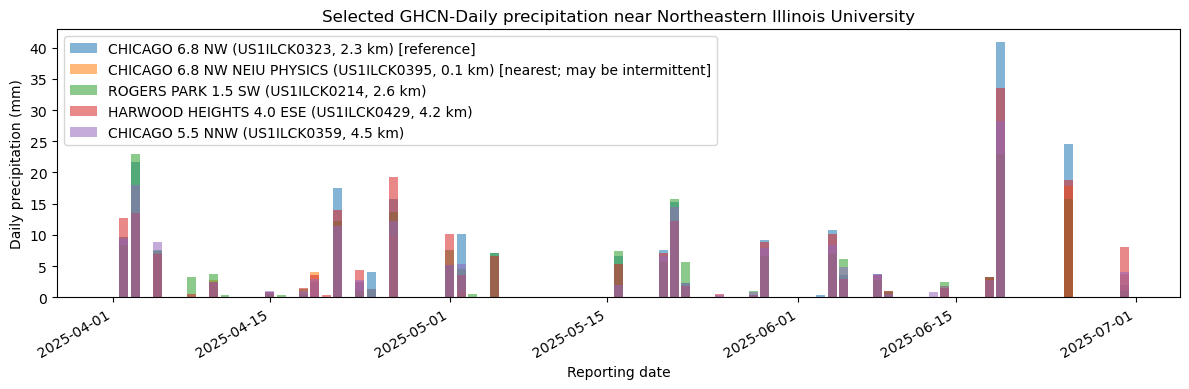

In [9]:
if ghcnd.empty:
    print("No GHCN-Daily precipitation is available to plot.")
else:
    adequate_plot_ids = (
        ghcnd_coverage.loc[
            ghcnd_coverage["coverage_fraction"] >= GHCN_MINIMUM_COVERAGE
        ]
        .sort_values(["distance_km", "station_id"])
        .head(GHCN_PLOT_STATIONS)["station_id"]
        .tolist()
    )
    nearest_station_id = ghcnd_coverage.sort_values(
        ["distance_km", "station_id"]
    ).iloc[0]["station_id"]

    plot_station_ids = list(dict.fromkeys(
        [ghcnd_reference_station, nearest_station_id, *adequate_plot_ids]
    ))

    fig, ax = plt.subplots(figsize=(12, 4))
    for station_id in plot_station_ids:
        group = ghcnd.loc[ghcnd["station_id"] == station_id]
        if group.empty:
            continue
        metadata = ghcnd_stations.loc[
            ghcnd_stations["station_id"] == station_id
        ]
        if metadata.empty:
            label = station_id
        else:
            row = metadata.iloc[0]
            label = (
                f"{row['station_name']} "
                f"({station_id}, {row['distance_km']:.1f} km)"
            )
        if station_id == ghcnd_reference_station:
            label += " [reference]"
        if station_id == nearest_station_id and station_id != ghcnd_reference_station:
            label += " [nearest; may be intermittent]"
        ax.bar(
            group.index,
            group["precip_mm"],
            width=0.8,
            alpha=0.55,
            label=label,
        )
    ax.set(
        title=f"Selected GHCN-Daily precipitation near {LOCATION_NAME}",
        ylabel="Daily precipitation (mm)",
        xlabel="Reporting date",
    )
    ax.legend(title=None)
    fig.autofmt_xdate()
    fig.tight_layout()

    figure_path = FIGURE_DIR / "ghcnd_daily_precipitation_neiu.png"
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    print(f"Saved {figure_path}")


## ASOS/AWOS hourly precipitation

The general ASOS/METAR archive can contain many routine and special reports during a single hour. Its raw `p01i` field is the precipitation accumulated since the station's previous hourly reset. Because several reports can contain overlapping accumulations, adding every raw `p01i` value can severely overcount precipitation.

This notebook therefore uses the IEM **computed hourly precipitation** service rather than summing raw METAR reports. IEM derives one nonoverlapping total for each station-hour from processed METAR observations. The timestamp is the ending hour of the interval.

IEM represents a trace as `0.0001` inch. The module stores its numerical accumulation as `0 mm` and preserves `trace = True`, avoiding both loss of the trace information and invented measurement precision.

The hourly observations use UTC timestamps. They are converted to `America/Chicago` before aggregation to local calendar days. These locally aggregated days may still differ from standardized ASOS daily climate summaries, which can follow local standard time throughout the year.

In [20]:
asos = pd.DataFrame()
asos_daily = pd.DataFrame()

if RUN_ASOS and not asos_stations.empty:
    selected_asos = asos_stations.head(3)["station_id"].tolist()
    try:
        asos = get_asos_hourly_precipitation(
            selected_asos,
            START_UTC,
            END_UTC,
            network=f"{STATE}_ASOS",
        )

        duplicate_station_hours = (
            asos.reset_index()
            .duplicated(["station_id", "time_utc"])
            .sum()
        )
        if duplicate_station_hours:
            raise PrecipitationDataError(
                "Computed ASOS data contain duplicate station-hours."
            )

        asos_daily = aggregate_interval_precipitation_daily(
            asos,
            timezone=TIMEZONE,
        )

        asos_summary = (
            asos.groupby("station_id")
            .agg(
                hourly_records=("precip_mm", "size"),
                wet_hours=("precip_mm", lambda values: (values > 0).sum()),
                trace_hours=("trace", "sum"),
                total_mm=("precip_mm", "sum"),
            )
        )

        display(asos.head())
        display(asos_summary)
        display(asos_daily.head())
        print(
            f"Retrieved {len(asos):,} nonoverlapping ASOS "
            "station-hour records."
        )
    except (PrecipitationDataError, ValueError) as exc:
        print(f"ASOS retrieval failed: {exc}")
else:
    print("ASOS retrieval skipped.")

,station_id,network,precip_mm,trace,latitude,longitude,state,source
time_utc,,,,,,,,
2025-04-01 05:00:00+00:00,MDW,IL_ASOS,0.0,False,41.78597,-87.75242,IL,IEM computed hourly ASOS precipitation
2025-04-01 06:00:00+00:00,MDW,IL_ASOS,0.0,False,41.78597,-87.75242,IL,IEM computed hourly ASOS precipitation
2025-04-01 07:00:00+00:00,MDW,IL_ASOS,0.0,False,41.78597,-87.75242,IL,IEM computed hourly ASOS precipitation
2025-04-01 08:00:00+00:00,MDW,IL_ASOS,0.0,False,41.78597,-87.75242,IL,IEM computed hourly ASOS precipitation
2025-04-01 09:00:00+00:00,MDW,IL_ASOS,0.0,False,41.78597,-87.75242,IL,IEM computed hourly ASOS precipitation


,hourly_records,wet_hours,trace_hours,total_mm
station_id,,,,
MDW,2172,117,146,230.886
ORD,2174,108,144,194.564


,station_id,precip_mm,observation_count,trace
date,,,,
2025-04-01,MDW,0.000,24,False
2025-04-01,ORD,0.000,24,False
2025-04-02,MDW,39.878,24,True
2025-04-02,ORD,31.750,24,True
2025-04-03,MDW,0.000,24,False


Retrieved 4,346 nonoverlapping ASOS station-hour records.


Saved figures/precipitation/asos_cumulative_precipitation_neiu.png


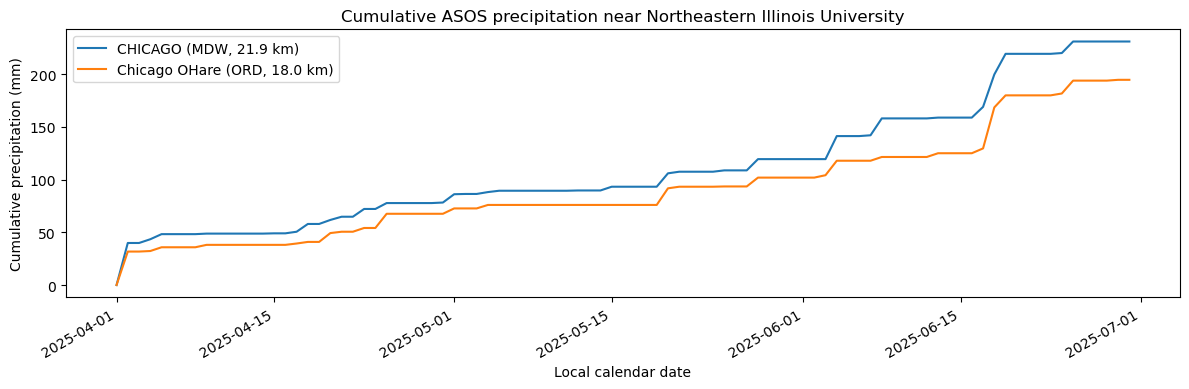

In [21]:
if asos_daily.empty:
    print("No ASOS daily precipitation is available to plot.")
else:
    fig, ax = plt.subplots(figsize=(12, 4))
    for station_id, group in asos_daily.groupby("station_id"):
        metadata = asos_stations.loc[
            asos_stations["station_id"] == station_id
        ]
        if metadata.empty:
            label = station_id
        else:
            row = metadata.iloc[0]
            label = (
                f"{row['station_name']} "
                f"({station_id}, {row['distance_km']:.1f} km)"
            )
        ax.plot(
            group.index,
            group["precip_mm"].cumsum(),
            label=label,
        )
    ax.set(
        title=f"Cumulative ASOS precipitation near {LOCATION_NAME}",
        ylabel="Cumulative precipitation (mm)",
        xlabel="Local calendar date",
    )
    ax.legend(title=None)
    fig.autofmt_xdate()
    fig.tight_layout()

    figure_path = FIGURE_DIR / "asos_cumulative_precipitation_neiu.png"
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    print(f"Saved {figure_path}")

## USGS precipitation measurements

USGS precipitation uses parameter code `00045`. The OGC API groups observations into uniquely identified time series. A monitoring location can contain more than one primary precipitation series when it operates multiple gauges or sublocations.

The Cicero example illustrates why `time_series_id` must be preserved: its original gauge and gauge `9B` are both primary, decumulated series but measure different totals. They are therefore retrieved, aggregated, labeled, and compared separately—never summed or averaged together.

For each time series, the notebook:

- verifies that timestamps are unique;
- infers the nominal reporting interval from the observation spacing;
- converts timestamps to `America/Chicago`;
- sums decumulated interval precipitation by local calendar date;
- calculates interval coverage for every day;
- masks totals for days below `USGS_MINIMUM_DAILY_COVERAGE`.

The period summary then identifies the nearest monitoring location with adequate daily coverage. All adequate primary gauges at that location are retained for comparison.

In [22]:
usgs = pd.DataFrame()
usgs_daily = pd.DataFrame()
usgs_period_coverage = pd.DataFrame()
usgs_reference_location = None
usgs_comparison_series = []

if RUN_USGS and not usgs_sites.empty:
    selected_usgs_series = usgs_sites["time_series_id"].tolist()
    try:
        usgs = get_usgs_precipitation(
            selected_usgs_series,
            START_UTC,
            END_UTC,
        )

        usgs_daily = aggregate_interval_precipitation_daily(
            usgs,
            timezone=TIMEZONE,
            station_column="time_series_id",
            trace_column=None,
            start_date=START_DATE,
            end_date=END_DATE,
            infer_expected_interval=True,
            minimum_coverage=USGS_MINIMUM_DAILY_COVERAGE,
        )

        usgs_period_coverage = (
            usgs_daily.groupby("time_series_id")
            .agg(
                expected_days=("complete_day", "size"),
                complete_days=("complete_day", "sum"),
                mean_interval_coverage=("coverage_fraction", "mean"),
                minimum_interval_coverage=("coverage_fraction", "min"),
                inferred_interval=("inferred_interval", "first"),
                total_precip_mm=("precip_mm", lambda x: x.sum(min_count=1)),
            )
            .reset_index()
        )
        usgs_period_coverage["period_coverage_fraction"] = (
            usgs_period_coverage["complete_days"]
            / usgs_period_coverage["expected_days"]
        )
        usgs_period_coverage = usgs_period_coverage.merge(
            usgs_sites,
            on="time_series_id",
            how="left",
        )

        if USGS_LOCATION_OVERRIDE is not None:
            if USGS_LOCATION_OVERRIDE not in set(
                usgs_period_coverage["monitoring_location_id"]
            ):
                raise PrecipitationDataError(
                    "USGS_LOCATION_OVERRIDE was not available for the "
                    "requested period."
                )
            usgs_reference_location = USGS_LOCATION_OVERRIDE
        else:
            adequate = usgs_period_coverage.loc[
                usgs_period_coverage["period_coverage_fraction"]
                >= USGS_MINIMUM_PERIOD_COVERAGE
            ].copy()
            if adequate.empty:
                fallback = usgs_period_coverage.sort_values(
                    ["period_coverage_fraction", "distance_km"],
                    ascending=[False, True],
                )
                usgs_reference_location = fallback.iloc[0][
                    "monitoring_location_id"
                ]
                print(
                    "Warning: no USGS time series met the period coverage "
                    "threshold; using the highest-coverage location."
                )
            else:
                usgs_reference_location = adequate.sort_values(
                    ["distance_km", "monitoring_location_id"]
                ).iloc[0]["monitoring_location_id"]

        usgs_comparison_series = usgs_period_coverage.loc[
            (
                usgs_period_coverage["monitoring_location_id"]
                == usgs_reference_location
            )
            & (
                usgs_period_coverage["period_coverage_fraction"]
                >= USGS_MINIMUM_PERIOD_COVERAGE
            ),
            "time_series_id",
        ].tolist()
        if not usgs_comparison_series:
            usgs_comparison_series = usgs_period_coverage.loc[
                usgs_period_coverage["monitoring_location_id"]
                == usgs_reference_location,
                "time_series_id",
            ].tolist()

        display(usgs.head())
        display(
            usgs_period_coverage[
                [
                    "time_series_id",
                    "monitoring_location_id",
                    "monitoring_location_name",
                    "sublocation_identifier",
                    "computation_identifier",
                    "inferred_interval",
                    "distance_km",
                    "complete_days",
                    "expected_days",
                    "period_coverage_fraction",
                    "total_precip_mm",
                ]
            ].round(3)
        )
        print(f"Retrieved {len(usgs):,} USGS precipitation observations.")
        print(
            "USGS comparison location selected by coverage, then distance: "
            f"{usgs_reference_location}"
        )
    except (PrecipitationDataError, ValueError) as exc:
        print(f"USGS retrieval failed: {exc}")
else:
    print("USGS retrieval skipped.")

,monitoring_location_id,precip_mm,value,unit_of_measure,qualifier,approval_status,time_series_id,parameter_code,source
time_utc,,,,,,,,,
2025-04-01 05:00:00+00:00,USGS-420910087490701,0.0,0.0,in,None,Approved,011f29aeb4964022ae5580136c9b6cf0,00045,USGS Water Data continuous values
2025-04-01 05:00:00+00:00,USGS-415518087583000,0.0,0.0,in,None,Approved,da085401d70c4a939c2bdd5d2de23c0a,00045,USGS Water Data continuous values
2025-04-01 05:05:00+00:00,USGS-420910087490701,0.0,0.0,in,None,Approved,011f29aeb4964022ae5580136c9b6cf0,00045,USGS Water Data continuous values
2025-04-01 05:10:00+00:00,USGS-420910087490701,0.0,0.0,in,None,Approved,011f29aeb4964022ae5580136c9b6cf0,00045,USGS Water Data continuous values
2025-04-01 05:15:00+00:00,USGS-420910087490701,0.0,0.0,in,None,Approved,011f29aeb4964022ae5580136c9b6cf0,00045,USGS Water Data continuous values


/tmp/ipykernel_289672/4254749965.py:114: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3)


,time_series_id,monitoring_location_id,monitoring_location_name,sublocation_identifier,computation_identifier,inferred_interval,distance_km,complete_days,expected_days,period_coverage_fraction,total_precip_mm
0,011f29aeb4964022ae5580136c9b6cf0,USGS-420910087490701,"RAIN GAGE AT NB CHICAGO RIVER AT DEERFIELD, IL",NaN,Decumulated,0 days 00:05:00,20.854,83,91,0.912,146.558
1,da085401d70c4a939c2bdd5d2de23c0a,USGS-415518087583000,"ADDISON WWTF AT ADDISON, IL",NaN,Decumulated,0 days 00:15:00,22.402,73,91,0.802,136.652
2,fb84da8ce24a4bd68bf92369834aa15e,USGS-415755087525300,"OHARE AIRPORT AT CHICAGO, IL",NaN,Decumulated,0 days 00:15:00,13.768,87,91,0.956,160.274


Retrieved 39,643 USGS precipitation observations.
USGS comparison location selected by coverage, then distance: USGS-415755087525300


Saved figures/precipitation/usgs_cumulative_precipitation_neiu.png


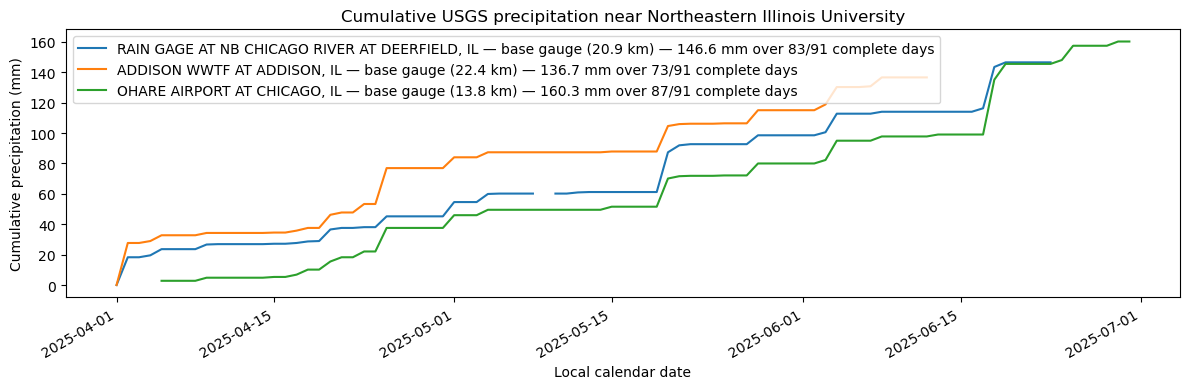

In [23]:
if usgs_daily.empty:
    print("No USGS daily precipitation is available to plot.")
else:
    fig, ax = plt.subplots(figsize=(12, 4))
    for time_series_id, group in usgs_daily.groupby("time_series_id"):
        metadata = usgs_sites.loc[
            usgs_sites["time_series_id"] == time_series_id
        ]
        if metadata.empty:
            label = time_series_id
        else:
            row = metadata.iloc[0]
            sublocation = row.get("sublocation_identifier")
            gauge = (
                f" — gauge {sublocation}"
                if pd.notna(sublocation)
                else " — base gauge"
            )
            label = (
                f"{row['monitoring_location_name']}{gauge} "
                f"({row['distance_km']:.1f} km)"
            )

        coverage_match = usgs_period_coverage.loc[
            usgs_period_coverage["time_series_id"] == time_series_id
        ]
        if not coverage_match.empty:
            coverage_row = coverage_match.iloc[0]
            label += (
                f" — {coverage_row['total_precip_mm']:.1f} mm over "
                f"{int(coverage_row['complete_days'])}/"
                f"{int(coverage_row['expected_days'])} complete days"
            )

        ax.plot(
            group.index,
            group["precip_mm"].cumsum(),
            label=label,
        )
    ax.set(
        title=f"Cumulative USGS precipitation near {LOCATION_NAME}",
        ylabel="Cumulative precipitation (mm)",
        xlabel="Local calendar date",
    )
    ax.legend(title=None)
    fig.autofmt_xdate()
    fig.tight_layout()

    figure_path = FIGURE_DIR / "usgs_cumulative_precipitation_neiu.png"
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    print(f"Saved {figure_path}")


## CoCoRaHS daily reports

The Community Collaborative Rain, Hail and Snow Network (CoCoRaHS) consists largely of volunteer observers using standardized manual gauges.

CoCoRaHS is spatially valuable because observers may be closer to a target site than an airport or long-term climate station. However:

- station participation can be intermittent;
- a station in the metadata may not have reported during the selected dates;
- daily totals generally represent a morning-to-morning accumulation;
- the reporting date should not be assumed to represent a midnight-to-midnight calendar day.

The IEM station directory contains many historical stations that are no longer active. The discovery step therefore filters each station's metadata archive period against the requested analysis dates before ranking by distance.

GHCN-Daily also contains CoCoRaHS observations. Its identifiers use a different form: for example, `US1ILCK0323` in GHCN-Daily corresponds to `IL-CK-323` in CoCoRaHS and IEM. The retrieval cell adds any nearby GHCN-Daily CoCoRaHS stations to the IEM candidate list. This cross-check helps avoid overlooking an active gauge simply because many closer historical stations filled the initial nearest-station list.

In [24]:
cocorahs = pd.DataFrame()
active_cocorahs = pd.DataFrame()

if RUN_COCORAHS:
    candidate_metadata = cocorahs_stations.copy()

    ghcnd_cocorahs = ghcnd_stations.loc[
        ghcnd_stations["station_id"].str.startswith("US1", na=False)
    ].copy()
    ghcnd_crosswalk_ids = []
    if not ghcnd_cocorahs.empty:
        ghcnd_cocorahs["station_id"] = ghcnd_cocorahs[
            "station_id"
        ].map(ghcnd_to_cocorahs_id)
        ghcnd_cocorahs = ghcnd_cocorahs.dropna(
            subset=["station_id"]
        )
        ghcnd_crosswalk_ids = ghcnd_cocorahs["station_id"].tolist()
        print(
            "CoCoRaHS IDs identified through GHCN-Daily: "
            + ", ".join(ghcnd_crosswalk_ids)
        )
        candidate_metadata = pd.concat(
            [candidate_metadata, ghcnd_cocorahs],
            ignore_index=True,
            sort=False,
        )

    if not candidate_metadata.empty:
        candidate_metadata = (
            candidate_metadata
            .sort_values("distance_km")
            .drop_duplicates("station_id", keep="first")
            .reset_index(drop=True)
        )
        candidate_ids = candidate_metadata["station_id"].tolist()
        print(
            f"Querying {len(candidate_ids)} unique CoCoRaHS stations "
            "through the IEM daily service."
        )

        try:
            cocorahs = get_cocorahs_precipitation(
                candidate_ids,
                START_DATE,
                END_DATE,
                state=STATE,
            )
            if not cocorahs.empty:
                active_ids = cocorahs["station_id"].dropna().unique()
                active_cocorahs = candidate_metadata.loc[
                    candidate_metadata["station_id"].isin(active_ids)
                ].copy()
                active_cocorahs = active_cocorahs.sort_values(
                    "distance_km"
                )
                display(
                    active_cocorahs.head(10)[
                        [
                            "station_id",
                            "station_name",
                            "distance_km",
                        ]
                    ]
                )
                display(cocorahs.head())
                print(
                    f"{len(active_ids)} of {len(candidate_ids)} candidate "
                    "stations returned observations."
                )
            else:
                print(
                    "No candidate CoCoRaHS station returned observations "
                    "from the IEM daily service during this period."
                )
        except PrecipitationDataError as exc:
            print(f"CoCoRaHS retrieval failed: {exc}")
    else:
        print("No CoCoRaHS candidates were available for retrieval.")
else:
    print("CoCoRaHS retrieval skipped.")

CoCoRaHS IDs identified through GHCN-Daily: IL-CK-395, IL-CK-323, IL-CK-168, IL-CK-214, IL-CK-94, IL-CK-429, IL-CK-359, IL-CK-232, IL-CK-371, IL-CK-321
Querying 26 unique CoCoRaHS stations through the IEM daily service.
No candidate CoCoRaHS station returned observations from the IEM daily service during this period.


In [26]:
if cocorahs.empty:
    print("No CoCoRaHS precipitation is available to plot.")
else:
    nearest_active = active_cocorahs.head(5)["station_id"].tolist()
    plot_data = cocorahs.loc[cocorahs["station_id"].isin(nearest_active)]

    fig, ax = plt.subplots(figsize=(12, 4))
    for station_id, group in plot_data.groupby("station_id"):
        metadata = active_cocorahs.loc[
            active_cocorahs["station_id"] == station_id
        ]
        if metadata.empty:
            label = station_id
        else:
            row = metadata.iloc[0]
            label = (
                f"{row['station_name']} "
                f"({station_id}, {row['distance_km']:.1f} km)"
            )
        ax.plot(
            group.index,
            group["precip_mm"].cumsum(),
            label=label,
        )
    ax.set(
        title=f"Cumulative CoCoRaHS precipitation near {LOCATION_NAME}",
        ylabel="Cumulative precipitation (mm)",
        xlabel="Reporting date",
    )
    ax.legend(title=None)
    fig.autofmt_xdate()
    fig.tight_layout()

No CoCoRaHS precipitation is available to plot.


## Comparison at a common daily scale

The comparison below uses:

- the GHCN-Daily station selected by daily coverage and then distance;
- the nearest `ASOS_COMPARISON_STATIONS` airport stations, using IEM-computed hourly totals aggregated by `America/Chicago` calendar day;
- every adequately complete primary USGS precipitation series at the nearest qualifying USGS monitoring location.

The direct IEM CoCoRaHS retrieval is not included in this final comparison. CoCoRaHS observations already present in GHCN-Daily remain eligible for selection, while the separate IEM route is retained as a station-discovery and exploratory section.

Two totals are reported:

1. **Available-data total:** each series is summed over every valid day it provides.
2. **Common-valid-day total:** every series is summed over the same intersection of dates on which all selected series are valid.

The common-valid-day comparison prevents a record outage from appearing to be an instrument disagreement. The notebook also displays dates excluded from the common comparison so that large storms during an outage are visible.

GHCN-Daily reporting days do not necessarily share the same boundaries as ASOS or USGS local calendar days. The comparison is therefore diagnostic. Differences can also be real because convective precipitation varies sharply over short distances and gauge exposure affects catch.


In [27]:
daily_frames = []
comparison_station_rows = []


def station_label(source, station_id, metadata):
    """Build a concise label for GHCN or ASOS station metadata."""
    match = metadata.loc[metadata["station_id"] == station_id]
    if match.empty:
        return f"{source} {station_id}", None, None

    row = match.iloc[0]
    name = row.get("station_name", station_id)
    distance = row.get("distance_km")
    if pd.notna(distance):
        label = f"{source} {name} ({station_id}, {distance:.1f} km)"
    else:
        label = f"{source} {name} ({station_id})"
    return label, name, distance


def usgs_series_label(time_series_id):
    """Build a label that distinguishes colocated USGS gauges."""
    match = usgs_sites.loc[
        usgs_sites["time_series_id"] == time_series_id
    ]
    if match.empty:
        return f"USGS {time_series_id}", None, None, None

    row = match.iloc[0]
    name = row.get("monitoring_location_name", row["monitoring_location_id"])
    sublocation = row.get("sublocation_identifier")
    gauge = (
        f"gauge {sublocation}"
        if pd.notna(sublocation)
        else "base gauge"
    )
    distance = row.get("distance_km")
    label = f"USGS {name} — {gauge} ({distance:.1f} km)"
    return label, name, distance, sublocation


if not ghcnd.empty and ghcnd_reference_station is not None:
    station_id = ghcnd_reference_station
    label, station_name, distance_km = station_label(
        "GHCN", station_id, ghcnd_stations
    )
    frame = ghcnd.loc[
        ghcnd["station_id"] == station_id,
        ["precip_mm"],
    ].copy()
    frame["source"] = "GHCN-Daily"
    frame["station_or_series_id"] = station_id
    frame["series"] = label
    daily_frames.append(frame)
    coverage_value = ghcnd_coverage.loc[
        ghcnd_coverage["station_id"] == station_id,
        "coverage_fraction",
    ].iloc[0]
    comparison_station_rows.append(
        {
            "source": "GHCN-Daily",
            "series": label,
            "station_or_series_id": station_id,
            "station_name": station_name,
            "distance_km": distance_km,
            "coverage_fraction": coverage_value,
        }
    )

if not asos_daily.empty:
    available = asos_stations.loc[
        asos_stations["station_id"].isin(
            asos_daily["station_id"].unique()
        )
    ].sort_values("distance_km")
    for station_id in available.head(
        ASOS_COMPARISON_STATIONS
    )["station_id"]:
        label, station_name, distance_km = station_label(
            "ASOS", station_id, asos_stations
        )
        frame = asos_daily.loc[
            asos_daily["station_id"] == station_id,
            ["precip_mm"],
        ].copy()
        frame["source"] = "ASOS hourly"
        frame["station_or_series_id"] = station_id
        frame["series"] = label
        daily_frames.append(frame)
        comparison_station_rows.append(
            {
                "source": "ASOS hourly",
                "series": label,
                "station_or_series_id": station_id,
                "station_name": station_name,
                "distance_km": distance_km,
                "coverage_fraction": pd.NA,
            }
        )

if not usgs_daily.empty:
    for time_series_id in usgs_comparison_series:
        label, station_name, distance_km, sublocation = usgs_series_label(
            time_series_id
        )
        frame = usgs_daily.loc[
            usgs_daily["time_series_id"] == time_series_id,
            ["precip_mm"],
        ].copy()
        frame["source"] = "USGS continuous"
        frame["station_or_series_id"] = time_series_id
        frame["series"] = label
        daily_frames.append(frame)
        coverage_value = usgs_period_coverage.loc[
            usgs_period_coverage["time_series_id"] == time_series_id,
            "period_coverage_fraction",
        ].iloc[0]
        comparison_station_rows.append(
            {
                "source": "USGS continuous",
                "series": label,
                "station_or_series_id": time_series_id,
                "station_name": station_name,
                "distance_km": distance_km,
                "coverage_fraction": coverage_value,
                "sublocation_identifier": sublocation,
            }
        )

comparison_stations = pd.DataFrame(comparison_station_rows)

if daily_frames:
    daily_comparison = pd.concat(daily_frames).reset_index()
    date_column = daily_comparison.columns[0]
    daily_comparison = daily_comparison.rename(columns={date_column: "date"})
    daily_comparison["date"] = pd.to_datetime(daily_comparison["date"])
    display(comparison_stations)
    display(daily_comparison.head())
else:
    daily_comparison = pd.DataFrame(
        columns=[
            "date",
            "precip_mm",
            "source",
            "station_or_series_id",
            "series",
        ]
    )
    print("No daily datasets are available for comparison.")


,source,series,station_or_series_id,station_name,distance_km,coverage_fraction,sublocation_identifier
0,GHCN-Daily,"GHCN CHICAGO 6.8 NW (US1ILCK0323, 2.3 km)",US1ILCK0323,CHICAGO 6.8 NW,2.317473,1.0,NaN
1,ASOS hourly,"ASOS Chicago OHare (ORD, 18.0 km)",ORD,Chicago OHare,17.953249,<NA>,NaN
2,ASOS hourly,"ASOS CHICAGO (MDW, 21.9 km)",MDW,CHICAGO,21.921070,<NA>,NaN
3,USGS continuous,"USGS OHARE AIRPORT AT CHICAGO, IL — base gauge...",fb84da8ce24a4bd68bf92369834aa15e,"OHARE AIRPORT AT CHICAGO, IL",13.768276,0.956044,NaN


,date,precip_mm,source,station_or_series_id,series
0,2025-04-01,0.0,GHCN-Daily,US1ILCK0323,"GHCN CHICAGO 6.8 NW (US1ILCK0323, 2.3 km)"
1,2025-04-02,9.7,GHCN-Daily,US1ILCK0323,"GHCN CHICAGO 6.8 NW (US1ILCK0323, 2.3 km)"
2,2025-04-03,21.6,GHCN-Daily,US1ILCK0323,"GHCN CHICAGO 6.8 NW (US1ILCK0323, 2.3 km)"
3,2025-04-04,0.0,GHCN-Daily,US1ILCK0323,"GHCN CHICAGO 6.8 NW (US1ILCK0323, 2.3 km)"
4,2025-04-05,7.4,GHCN-Daily,US1ILCK0323,"GHCN CHICAGO 6.8 NW (US1ILCK0323, 2.3 km)"


,source,station_or_series_id,series,available_days,available_total_mm,common_valid_days,common_valid_total_mm,available_difference_from_ghcnd_mm,common_difference_from_ghcnd_mm
0,ASOS hourly,MDW,"ASOS CHICAGO (MDW, 21.9 km)",91,230.89,87,187.45,-8.91,-21.05
1,ASOS hourly,ORD,"ASOS Chicago OHare (ORD, 18.0 km)",91,194.56,87,162.31,-45.24,-46.19
2,GHCN-Daily,US1ILCK0323,"GHCN CHICAGO 6.8 NW (US1ILCK0323, 2.3 km)",91,239.80,87,208.50,0.00,0.00
3,USGS continuous,fb84da8ce24a4bd68bf92369834aa15e,"USGS OHARE AIRPORT AT CHICAGO, IL — base gauge...",87,160.27,87,160.27,-79.53,-48.23


4 date(s) are excluded from the common-valid-day comparison because at least one series is missing or incomplete.


series,"ASOS CHICAGO (MDW, 21.9 km)","ASOS Chicago OHare (ORD, 18.0 km)","GHCN CHICAGO 6.8 NW (US1ILCK0323, 2.3 km)","USGS OHARE AIRPORT AT CHICAGO, IL — base gauge (13.8 km)"
date,,,,
2025-04-01,0.000,0.000,0.0,NaN
2025-04-02,39.878,31.750,9.7,NaN
2025-04-03,0.000,0.000,21.6,NaN
2025-04-04,3.556,0.508,0.0,NaN


Saved figures/precipitation/precipitation_cumulative_comparison_neiu.png
Saved figures/precipitation/precipitation_cumulative_common_days_neiu.png


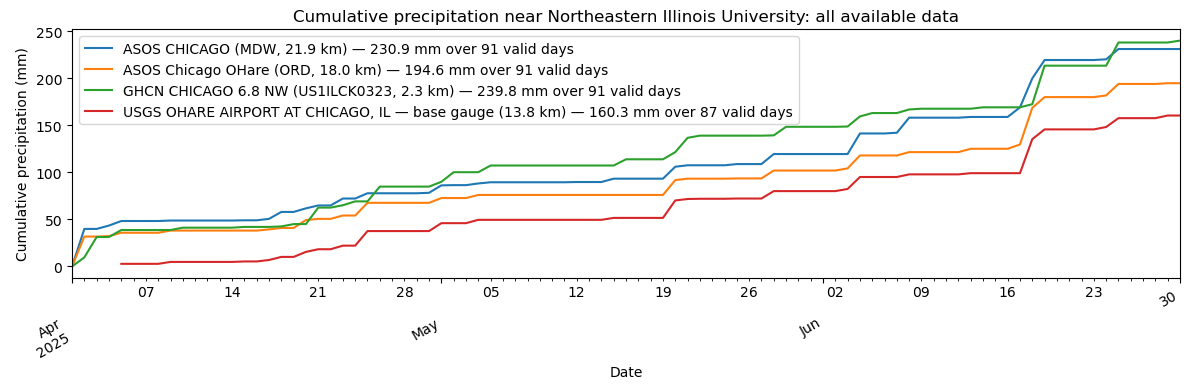

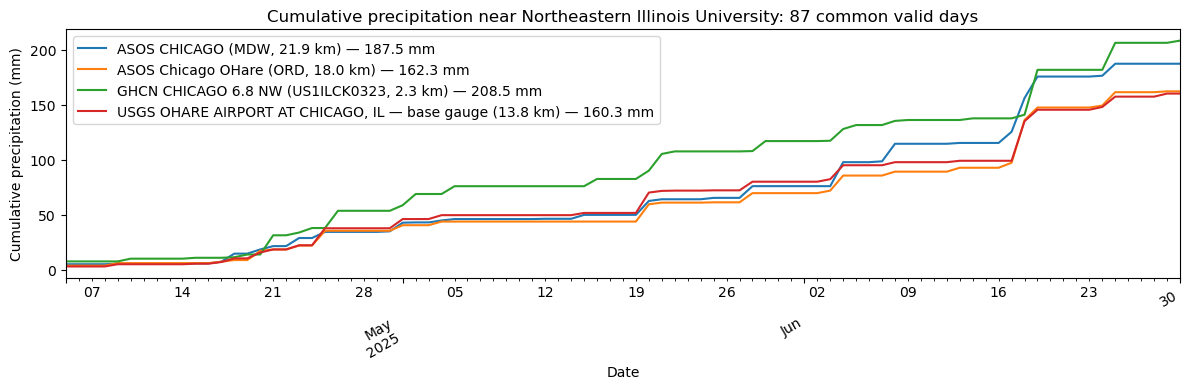

In [28]:
if daily_comparison.empty:
    print("No daily comparison is available to plot.")
else:
    duplicate_daily_rows = daily_comparison.duplicated(
        ["date", "series"]
    ).sum()
    if duplicate_daily_rows:
        raise PrecipitationDataError(
            "Daily comparison contains duplicate date-series rows."
        )

    wide_available = daily_comparison.pivot(
        index="date",
        columns="series",
        values="precip_mm",
    ).sort_index()
    wide_common = wide_available.dropna(how="any")

    series_metadata = comparison_stations.drop_duplicates("series").set_index(
        "series"
    )
    comparison_summary = pd.DataFrame(
        {
            "available_total_mm": wide_available.sum(min_count=1),
            "available_days": wide_available.notna().sum(),
            "common_valid_total_mm": wide_common.sum(min_count=1),
        }
    ).reset_index()
    comparison_summary["common_valid_days"] = len(wide_common)
    comparison_summary = comparison_summary.merge(
        series_metadata.reset_index(),
        on="series",
        how="left",
        validate="one_to_one",
    )

    ghcnd_rows = comparison_summary.loc[
        comparison_summary["source"] == "GHCN-Daily"
    ]
    if len(ghcnd_rows) == 1:
        ghcnd_available_total = float(
            ghcnd_rows["available_total_mm"].iloc[0]
        )
        ghcnd_common_total = float(
            ghcnd_rows["common_valid_total_mm"].iloc[0]
        )
        comparison_summary["available_difference_from_ghcnd_mm"] = (
            comparison_summary["available_total_mm"]
            - ghcnd_available_total
        )
        comparison_summary["common_difference_from_ghcnd_mm"] = (
            comparison_summary["common_valid_total_mm"]
            - ghcnd_common_total
        )

    summary_columns = [
        "source",
        "station_or_series_id",
        "series",
        "available_days",
        "available_total_mm",
        "common_valid_days",
        "common_valid_total_mm",
        "available_difference_from_ghcnd_mm",
        "common_difference_from_ghcnd_mm",
    ]
    summary_columns = [
        column
        for column in summary_columns
        if column in comparison_summary.columns
    ]
    display(comparison_summary[summary_columns].round(2))

    excluded_dates = wide_available.loc[
        wide_available.isna().any(axis=1)
    ].copy()
    if excluded_dates.empty:
        print("All selected series share the same valid dates.")
    else:
        print(
            f"{len(excluded_dates)} date(s) are excluded from the "
            "common-valid-day comparison because at least one series is "
            "missing or incomplete."
        )
        display(excluded_dates)

    available_labels = {
        row.series: (
            f"{row.series} — {row.available_total_mm:.1f} mm over "
            f"{int(row.available_days)} valid days"
        )
        for row in comparison_summary.itertuples(index=False)
    }
    available_cumulative = wide_available.cumsum().rename(
        columns=available_labels
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    available_cumulative.plot(ax=ax)
    ax.set(
        title=(
            f"Cumulative precipitation near {LOCATION_NAME}: "
            "all available data"
        ),
        ylabel="Cumulative precipitation (mm)",
        xlabel="Date",
    )
    ax.legend(title=None)
    fig.autofmt_xdate()
    fig.tight_layout()

    available_figure_path = (
        FIGURE_DIR / "precipitation_cumulative_comparison_neiu.png"
    )
    fig.savefig(available_figure_path, dpi=200, bbox_inches="tight")
    print(f"Saved {available_figure_path}")

    if not wide_common.empty:
        common_labels = {
            row.series: (
                f"{row.series} — {row.common_valid_total_mm:.1f} mm"
            )
            for row in comparison_summary.itertuples(index=False)
        }
        common_cumulative = wide_common.cumsum().rename(
            columns=common_labels
        )

        fig, ax = plt.subplots(figsize=(12, 4))
        common_cumulative.plot(ax=ax)
        ax.set(
            title=(
                f"Cumulative precipitation near {LOCATION_NAME}: "
                f"{len(wide_common)} common valid days"
            ),
            ylabel="Cumulative precipitation (mm)",
            xlabel="Date",
        )
        ax.legend(title=None)
        fig.autofmt_xdate()
        fig.tight_layout()

        common_figure_path = (
            FIGURE_DIR / "precipitation_cumulative_common_days_neiu.png"
        )
        fig.savefig(common_figure_path, dpi=200, bbox_inches="tight")
        print(f"Saved {common_figure_path}")


## Coverage and missing-data diagnostics

In [29]:
coverage_rows = []

source_definitions = [
    ("GHCN-Daily", ghcnd, "station_id", ghcnd_stations),
    ("ASOS hourly", asos, "station_id", asos_stations),
    ("USGS daily", usgs_daily, "time_series_id", usgs_sites),
    ("CoCoRaHS daily", cocorahs, "station_id", active_cocorahs),
]

for source_name, frame, station_column, metadata in source_definitions:
    if frame.empty:
        continue
    for station_id, group in frame.groupby(station_column):
        station_name = pd.NA
        distance_km = pd.NA
        sublocation = pd.NA
        if not metadata.empty and station_column in metadata.columns:
            match = metadata.loc[metadata[station_column] == station_id]
            if not match.empty:
                row = match.iloc[0]
                station_name = row.get(
                    "station_name",
                    row.get("monitoring_location_name", pd.NA),
                )
                distance_km = row.get("distance_km", pd.NA)
                sublocation = row.get("sublocation_identifier", pd.NA)

        coverage_rows.append(
            {
                "source": source_name,
                "station_or_series_id": station_id,
                "station_name": station_name,
                "sublocation_identifier": sublocation,
                "distance_km": distance_km,
                "observations": len(group),
                "first_time": group.index.min(),
                "last_time": group.index.max(),
                "missing_precip": int(group["precip_mm"].isna().sum()),
                "total_precip_mm": group["precip_mm"].sum(min_count=1),
            }
        )

coverage = pd.DataFrame(coverage_rows)
if not coverage.empty:
    coverage = coverage.sort_values(["source", "distance_km"])
display(coverage)

,source,station_or_series_id,station_name,sublocation_identifier,distance_km,observations,first_time,last_time,missing_precip,total_precip_mm
10,ASOS hourly,ORD,Chicago OHare,<NA>,17.953249,2174,2025-04-01 05:00:00+00:00,2025-07-01 04:00:00+00:00,0,194.564
9,ASOS hourly,MDW,CHICAGO,<NA>,21.921070,2172,2025-04-01 05:00:00+00:00,2025-07-01 04:00:00+00:00,0,230.886
7,GHCN-Daily,US1ILCK0395,CHICAGO 6.8 NW NEIU PHYSICS,<NA>,0.129372,38,2025-04-04 00:00:00,2025-06-30 00:00:00,0,51.100
4,GHCN-Daily,US1ILCK0323,CHICAGO 6.8 NW,<NA>,2.317473,91,2025-04-01 00:00:00,2025-06-30 00:00:00,0,239.800
1,GHCN-Daily,US1ILCK0214,ROGERS PARK 1.5 SW,<NA>,2.581490,89,2025-04-01 00:00:00,2025-06-30 00:00:00,0,200.500
0,GHCN-Daily,US1ILCK0094,LINCOLNWOOD 1.8 E,<NA>,2.722317,70,2025-04-01 00:00:00,2025-06-30 00:00:00,0,174.200
8,GHCN-Daily,US1ILCK0429,HARWOOD HEIGHTS 4.0 ESE,<NA>,4.200684,91,2025-04-01 00:00:00,2025-06-30 00:00:00,0,219.400
5,GHCN-Daily,US1ILCK0359,CHICAGO 5.5 NNW,<NA>,4.498585,85,2025-04-01 00:00:00,2025-06-30 00:00:00,0,171.500
2,GHCN-Daily,US1ILCK0232,ROGERS PARK 0.6 ESE,<NA>,4.623023,90,2025-04-01 00:00:00,2025-06-30 00:00:00,0,200.900
6,GHCN-Daily,US1ILCK0371,EVANSTON 1.2 S,<NA>,5.664394,89,2025-04-01 00:00:00,2025-06-30 00:00:00,0,186.300


## MWRD rain gauges

The [MWRD Rain Gauge Viewer](https://gispub.mwrd.org/raingaugeviewer/) provides valuable local observations for the Chicago region. The viewer currently supports interactive date selection and CSV export, but this project does not yet rely on an undocumented automated request.

A practical interim workflow is:

1. Choose a gauge and date range in the viewer.
2. Export the results as CSV.
3. Save the untouched export under `data/precipitation/raw/mwrd/`.
4. Inspect the column names and metadata.
5. Convert the timestamp and precipitation fields explicitly in a documented notebook cell.

**Manual step required:** leaving `MWRD_CSV = None` is expected and causes this section to skip without error.

The following optional cell loads a manually downloaded CSV without assuming a particular schema. It displays the columns so that the mapping can be defined after a real MWRD export has been examined.

In [30]:
MWRD_CSV = None
# Example:
# MWRD_CSV = Path("data/precipitation/raw/mwrd/example.csv")

if MWRD_CSV is None:
    print("MWRD import skipped: set MWRD_CSV after manually exporting a CSV.")
else:
    mwrd_raw = pd.read_csv(MWRD_CSV)
    print("MWRD columns:")
    print(mwrd_raw.columns.tolist())
    display(mwrd_raw.head())


MWRD import skipped: set MWRD_CSV after manually exporting a CSV.


## Data provenance and interpretation

For reproducible work, record at least:

- source and service endpoint;
- station identifier and station name;
- station coordinates and distance from the study location;
- native temporal resolution;
- units before and after conversion;
- reporting-day definition;
- retrieval date;
- quality, trace, qualifier, and approval flags;
- missing intervals;
- any transformations or aggregation.

Recommended principles:

1. Keep original downloads or API responses when practical.
2. Do not interpolate precipitation across missing intervals merely to make a continuous plot.
3. Preserve trace flags.
4. Do not compare daily values until their observation-period definitions are understood.
5. Treat spatial disagreement as a scientific result to investigate, not automatically as an error.
6. Inspect USGS series metadata before computing daily totals.


## References

### NOAA NCEI

- [Global Historical Climatology Network-Daily](https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily)
- [GHCN-Daily file documentation](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme.txt)
- [GHCN-Daily by-station documentation](https://www.ncei.noaa.gov/pub/data/ghcn/daily/readme-by_station.txt)
- [GHCN-Daily public files](https://www.ncei.noaa.gov/pub/data/ghcn/daily/)

### Iowa Environmental Mesonet

- [IEM API services](https://mesonet.agron.iastate.edu/api/)
- [IEM station-network GeoJSON service](https://mesonet.agron.iastate.edu/geojson/network.py?help=)
- [ASOS/AWOS/METAR data request](https://mesonet.agron.iastate.edu/request/download.phtml)
- [ASOS request backend](https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?help=)
- [ASOS precipitation notes](https://mesonet.agron.iastate.edu/ASOS/precipnote.phtml)
- [Daily-summary request backend](https://mesonet.agron.iastate.edu/cgi-bin/request/daily.py?help=)
- [IEM CoCoRaHS archive](https://mesonet.agron.iastate.edu/cocorahs/)

### USGS

- [USGS Water Data OGC API guide](https://api.waterdata.usgs.gov/docs/ogcapi/)
- [Time-series metadata schema](https://api.waterdata.usgs.gov/ogcapi/v0/collections/time-series-metadata/schema?f=html)
- [Continuous-values documentation](https://api.waterdata.usgs.gov/ogcapi/v0/collections/continuous?f=html)

- [USGS Water Data APIs](https://api.waterdata.usgs.gov/)
- [Getting started with the OGC APIs](https://api.waterdata.usgs.gov/docs/ogcapi/)
- [USGS parameter codes](https://api.waterdata.usgs.gov/ogcapi/v0/collections/parameter-codes/items)

### Other

- [CoCoRaHS](https://www.cocorahs.org/)
- [MWRD Rain Gauge Viewer](https://gispub.mwrd.org/raingaugeviewer/)

- IEM computed hourly precipitation: https://mesonet.agron.iastate.edu/request/hourlyprecip.phtml
- IEM hourly-precipitation backend: https://mesonet.agron.iastate.edu/cgi-bin/request/hourlyprecip.py?help=
